# Modélisation KNN — Classification des alertes cybersécurité Microsoft

**Branche :** `Guyjc-Modélisation`  
**Auteur :** Guy Junior Calvet  
**Objectif :** Construire un modèle K-Nearest Neighbors (KNN) optimisé pour classifier les incidents de sécurité Microsoft en 3 classes : `BenignPositive`, `FalsePositive`, `TruePositive`.

### Architecture
Le **prétraitement et l'exploration des données** sont réalisés dans `notebook.ipynb` (branche `main`). Ce fichier exporte un CSV prétraité (`donnees_preprocessees.csv`) que le présent notebook charge directement pour la **modélisation**.

### Pipeline de modélisation
1. **Chargement des données prétraitées** via `donnees_preprocessees.csv`
2. **Réduction de dimensionnalité par ACP (PCA)** — compression des features
3. **Modèle KNN de base** (baseline K=5)
4. **Recherche du K optimal** (Elbow Method + Cross-Validation)
5. **Optimisation par GridSearchCV** (hyperparamètres complets)
6. **Évaluation finale** (métriques, matrice de confusion, rapport de classification)

### Sources & Références
- Assistance IA pour debugging
- Scikit-learn KNN : https://scikit-learn.org/stable/modules/neighbors.html
- Scikit-learn PCA : https://scikit-learn.org/stable/modules/decomposition.html#pca
- Dataset GUIDE : https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction
- Cover, T. & Hart, P. (1967). *Nearest neighbor pattern classification*. IEEE Transactions on Information Theory.
- Scikit-learn GridSearchCV : https://scikit-learn.org/stable/modules/grid_search.html.
- Notes de cours (Forage des données et Analyse statistiques des données de masse)

## 1. Importation des bibliothèques

In [1]:
# -- Bibliotheques standard --
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# -- Scikit-learn : modelisation --
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# -- Scikit-learn : metriques --
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score,
    precision_score, recall_score
)

# -- Constantes --
# Cible binaire (nouveau pretraitement equipe) : 0 = Non-TP, 1 = TP
CIBLE_MAP = {'Non-TruePositive': 0, 'TruePositive': 1}
CIBLE_MAP_INV = {v: k for k, v in CIBLE_MAP.items()}
TARGET_NAMES = ['Non-TP (0)', 'TP (1)']

print("Bibliotheques importees avec succes.")

Bibliotheques importees avec succes.


## 2. Chargement des donnees pretraitees et transformation

Les donnees ont ete **pretraitees et explorees** dans `notebook.ipynb` (branche `main`) et sauvegardees dans `donnees_preprocessees.csv`. Le pretraitement comprend :

| Etape | Action |
|-------|--------|
| **Selection** | 14 colonnes utiles, suppression des identifiants |
| **NaN** | Remplissage par `'Unknown'` / `'None'` selon la colonne |
| **Cardinalite** | `MitreTechniques` top 15 ; colonnes geo top N |
| **Features** | `IsWeekend`, `IsBusinessHour` ; `RegistryValueData` en str |
| **Cible** | `BenignPositive=0`, `FalsePositive=1`, `TruePositive=2` |

Ce notebook effectue le **split train/test** et la **transformation** (StandardScaler + OneHotEncoder) avant la modelisation.

In [2]:
# -- 2.1 Chargement du dataset pretraite --
df = pd.read_csv("donnees_preprocessees.csv", low_memory=False)
print(f"Dimensions : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")

# Separation X / y
X = df.drop(columns=['cible'])
y = df['cible']

# Identifier les colonnes numeriques et categorielles
num_cols = X.select_dtypes(exclude='object').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype(str)

print(f"\n  Numeriques    ({len(num_cols)}) : {num_cols}")
print(f"  Categorielles ({len(cat_cols)}) : {cat_cols}")
print(f"\n  Distribution cible :")
print(y.map(CIBLE_MAP_INV).value_counts().to_string())

# -- 2.2 Split stratifie (80/20) --
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026, stratify=y
)
print(f"\n  Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")

# -- 2.3 Transformation (StandardScaler + OneHotEncoder) --
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                              sparse_output=False), cat_cols),
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

print(f"\n  Dimensionnalite apres OneHotEncoding : {X_train_transformed.shape[1]} features")
print(f"  Train : {X_train_transformed.shape}  |  Test : {X_test_transformed.shape}")

Dimensions : 94,638 lignes x 21 colonnes

  Numeriques    (6) : ['RegistryValueData', 'OSFamily', 'OSVersion', 'Month', 'IsWeekend', 'IsBusinessHour']
  Categorielles (14) : ['AlertTitle', 'Category', 'MitreTechniques', 'ActionGrouped', 'ActionGranular', 'EntityType', 'ThreatFamily', 'ResourceType', 'Roles', 'EvidenceRole', 'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode']

  Distribution cible :
cible
Non-TruePositive    61418
TruePositive        33220

  Train : 75,710  |  Test : 18,928

  Dimensionnalite apres OneHotEncoding : 185 features
  Train : (75710, 185)  |  Test : (18928, 185)

  Dimensionnalite apres OneHotEncoding : 185 features
  Train : (75710, 185)  |  Test : (18928, 185)


## 3. Réduction de dimensionnalité — Analyse en Composantes Principales (ACP / PCA)

### Pourquoi appliquer la PCA ?
Après le `OneHotEncoding`, le nombre de features augmente considérablement (~173 dimensions). Or, KNN est particulièrement sensible à la **malédiction de la dimensionnalité** (Bellman, 1961) : dans un espace de grande dimension, les distances entre points deviennent quasi uniformes, réduisant le pouvoir discriminant du modèle.

La PCA projette les données dans un sous-espace de dimension réduite tout en conservant le maximum de **variance expliquée** avec $K \ll p$ composantes principales retenues.

### Seuil retenu : 95% de la variance
On conserve le nombre minimal de composantes qui expliquent au moins **95%** de la variance totale — un seuil standard en apprentissage automatique (Jolliffe, 2002).

In [3]:
# -- 3.1 Analyse de la variance expliquee --

# Fit PCA complet pour analyser la distribution de la variance
pca_full = PCA(random_state=2026)
pca_full.fit(X_train_transformed)

variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_)

# Nombre de composantes pour 95% de variance
n_composantes_95 = np.argmax(variance_cumulee >= 0.95) + 1

print(f"Dimensions originales : {X_train_transformed.shape[1]} features")
print(f"Composantes pour 95% de variance : {n_composantes_95}")
print(f"Taux de compression : {(1 - n_composantes_95/X_train_transformed.shape[1])*100:.1f}%")
print(f"\nVariance expliquee par les 5 premieres composantes :")
for i in range(5):
    print(f"  PC{i+1} : {pca_full.explained_variance_ratio_[i]*100:.2f}%  (cumule : {variance_cumulee[i]*100:.2f}%)")

Dimensions originales : 185 features
Composantes pour 95% de variance : 28
Taux de compression : 84.9%

Variance expliquee par les 5 premieres composantes :
  PC1 : 21.34%  (cumule : 21.34%)
  PC2 : 11.90%  (cumule : 33.24%)
  PC3 : 10.43%  (cumule : 43.67%)
  PC4 : 10.01%  (cumule : 53.68%)
  PC5 : 9.19%  (cumule : 62.87%)


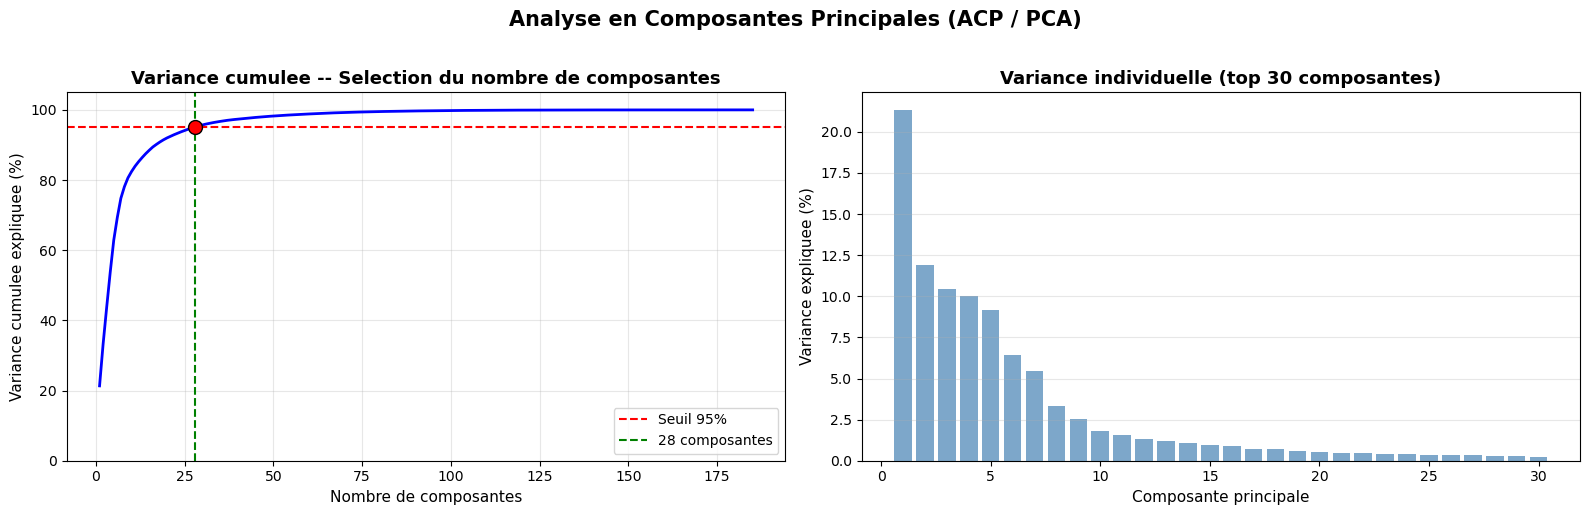


On retient 28 composantes (95% de variance, compression de 85%)


In [4]:
# -- 3.2 Visualisation de la variance cumulee --

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphique 1 : Variance cumulee
axes[0].plot(range(1, len(variance_cumulee) + 1), variance_cumulee * 100, 'b-', linewidth=2)
axes[0].axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='Seuil 95%')
axes[0].axvline(x=n_composantes_95, color='green', linestyle='--', linewidth=1.5,
                label=f'{n_composantes_95} composantes')
axes[0].scatter([n_composantes_95], [95], color='red', s=100, zorder=5, edgecolors='black')
axes[0].set_xlabel('Nombre de composantes', fontsize=11)
axes[0].set_ylabel('Variance cumulee expliquee (%)', fontsize=11)
axes[0].set_title('Variance cumulee -- Selection du nombre de composantes',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 105)

# Graphique 2 : Variance individuelle (top 30 composantes)
n_show = min(30, len(pca_full.explained_variance_ratio_))
axes[1].bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
            color='steelblue', alpha=0.7)
axes[1].set_xlabel('Composante principale', fontsize=11)
axes[1].set_ylabel('Variance expliquee (%)', fontsize=11)
axes[1].set_title(f'Variance individuelle (top {n_show} composantes)',
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Analyse en Composantes Principales (ACP / PCA)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nOn retient {n_composantes_95} composantes (95% de variance, "
      f"compression de {(1 - n_composantes_95/X_train_transformed.shape[1])*100:.0f}%)")

In [5]:
# -- 3.3 Application de la PCA (95% de variance) --

pca = PCA(n_components=0.95, random_state=2026)
X_train_pca = pca.fit_transform(X_train_transformed)
X_test_pca  = pca.transform(X_test_transformed)

print(f"Transformation PCA appliquee :")
print(f"  Train : {X_train_transformed.shape} -> {X_train_pca.shape}")
print(f"  Test  : {X_test_transformed.shape} -> {X_test_pca.shape}")
print(f"  Composantes retenues : {pca.n_components_}")
print(f"  Variance expliquee   : {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\nDonnees pretes pour la modelisation KNN avec PCA.")

Transformation PCA appliquee :
  Train : (75710, 185) -> (75710, 28)
  Test  : (18928, 185) -> (18928, 28)
  Composantes retenues : 28
  Variance expliquee   : 95.16%

Donnees pretes pour la modelisation KNN avec PCA.


## 4. Modèle KNN Baseline (K=5) — Sans PCA vs Avec PCA

On commence par un modèle KNN de référence avec `K=5` (valeur par défaut scikit-learn) pour établir une **baseline** avant toute optimisation. On compare les performances **sans** et **avec** la réduction PCA pour quantifier son impact.

In [8]:
# -- 4.1 KNN Baseline (K=5) -- Sans PCA vs Avec PCA --

# --- Sans PCA (toutes les features) ---
knn_baseline_nopca = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn_baseline_nopca.fit(X_train_transformed, y_train)
y_pred_bl_nopca = knn_baseline_nopca.predict(X_test_transformed)

acc_bl_nopca = accuracy_score(y_test, y_pred_bl_nopca)
f1_bl_nopca  = f1_score(y_test, y_pred_bl_nopca, average='macro')

# --- Avec PCA ---
knn_baseline = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn_baseline.fit(X_train_pca, y_train)
y_pred_baseline = knn_baseline.predict(X_test_pca)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline  = f1_score(y_test, y_pred_baseline, average='macro')

print("=" * 65)
print("        KNN BASELINE (K=5) -- IMPACT DE LA PCA")
print("=" * 65)
print(f"\n  {'Configuration':<25} {'Accuracy':>10} {'Macro F1':>10} {'Features':>10}")
print(f"  {'-' * 55}")
print(f"  {'Sans PCA':<25} {acc_bl_nopca:>10.4f} {f1_bl_nopca:>10.4f} {X_train_transformed.shape[1]:>10}")
print(f"  {'Avec PCA (95% var.)':<25} {acc_baseline:>10.4f} {f1_baseline:>10.4f} {X_train_pca.shape[1]:>10}")
print(f"\n  Delta F1 (PCA - Sans PCA) : {f1_baseline - f1_bl_nopca:+.4f}")
print(f"  Compression : {X_train_transformed.shape[1]} -> {X_train_pca.shape[1]} features "
      f"(-{(1 - X_train_pca.shape[1]/X_train_transformed.shape[1])*100:.0f}%)")
print(f"\n{'-' * 65}")
print("\nRapport de classification (Avec PCA) :")
print(classification_report(
    y_test, y_pred_baseline,
    target_names=TARGET_NAMES
))

        KNN BASELINE (K=5) -- IMPACT DE LA PCA

  Configuration               Accuracy   Macro F1   Features
  -------------------------------------------------------
  Sans PCA                      0.7787     0.7460        185
  Avec PCA (95% var.)           0.7780     0.7453         28

  Delta F1 (PCA - Sans PCA) : -0.0007
  Compression : 185 -> 28 features (-85%)

-----------------------------------------------------------------

Rapport de classification (Avec PCA) :
              precision    recall  f1-score   support

  Non-TP (0)       0.80      0.88      0.84     12284
      TP (1)       0.72      0.60      0.65      6644

    accuracy                           0.78     18928
   macro avg       0.76      0.74      0.75     18928
weighted avg       0.77      0.78      0.77     18928



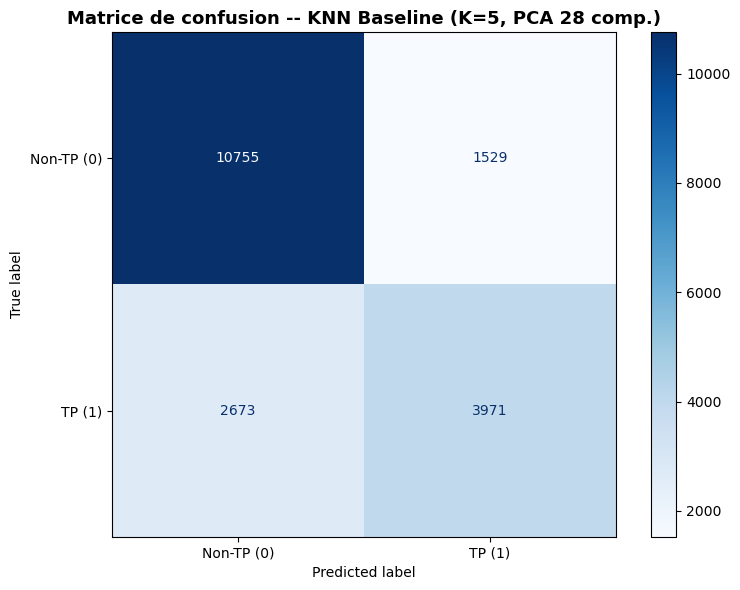

In [10]:
# -- 4.2 Matrice de confusion -- Baseline avec PCA --
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    display_labels=TARGET_NAMES,
    cmap='Blues', ax=ax
)
ax.set_title(f'Matrice de confusion -- KNN Baseline (K=5, PCA {X_train_pca.shape[1]} comp.)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Recherche du K optimal -- Elbow Method avec Cross-Validation

### Methodologie
Le choix de K est l'hyperparametre le plus critique pour KNN :
- **K trop petit** : surapprentissage (sensibilite au bruit)
- **K trop grand** : sous-apprentissage (frontieres trop lissees)

On utilise la **methode du coude (Elbow Method)** combinee a une **validation croisee stratifiee a 3 plis** sur les donnees reduites par PCA. Avec ~75 000 lignes d'entrainement, 3 folds offrent un bon compromis : chaque fold de validation contient ~25 000 observations, ce qui est largement suffisant pour une estimation stable des performances.

In [11]:
# -- 5.1 Elbow Method : K de 1 a 21 (impairs) --
# 3-fold CV sur donnees PCA : ~25k observations par fold = estimation stable

k_range = list(range(1, 22, 2))  # [1, 3, 5, 7, ..., 21]
cv_scores_mean = []
cv_scores_std  = []

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=2026)

print(f"Recherche du K optimal ({X_train_pca.shape[1]} composantes PCA, 3-fold CV)")
print(f"K testes : {k_range}\n")

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(knn, X_train_pca, y_train, cv=skf,
                             scoring='f1_macro', n_jobs=-1)
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())
    print(f"  K={k:2d}  |  Macro F1 = {scores.mean():.4f} (+/-{scores.std():.4f})")

best_idx = np.argmax(cv_scores_mean)
best_k   = k_range[best_idx]
print(f"\nMeilleur K = {best_k} avec Macro F1 = {cv_scores_mean[best_idx]:.4f}")

Recherche du K optimal (28 composantes PCA, 3-fold CV)
K testes : [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]



  K= 1  |  Macro F1 = 0.7111 (+/-0.0036)
  K= 3  |  Macro F1 = 0.7453 (+/-0.0044)
  K= 3  |  Macro F1 = 0.7453 (+/-0.0044)
  K= 5  |  Macro F1 = 0.7455 (+/-0.0040)
  K= 5  |  Macro F1 = 0.7455 (+/-0.0040)
  K= 7  |  Macro F1 = 0.7500 (+/-0.0061)
  K= 7  |  Macro F1 = 0.7500 (+/-0.0061)
  K= 9  |  Macro F1 = 0.7553 (+/-0.0017)
  K= 9  |  Macro F1 = 0.7553 (+/-0.0017)
  K=11  |  Macro F1 = 0.7578 (+/-0.0041)
  K=11  |  Macro F1 = 0.7578 (+/-0.0041)
  K=13  |  Macro F1 = 0.7605 (+/-0.0050)
  K=13  |  Macro F1 = 0.7605 (+/-0.0050)
  K=15  |  Macro F1 = 0.7601 (+/-0.0057)
  K=15  |  Macro F1 = 0.7601 (+/-0.0057)
  K=17  |  Macro F1 = 0.7631 (+/-0.0036)
  K=17  |  Macro F1 = 0.7631 (+/-0.0036)
  K=19  |  Macro F1 = 0.7638 (+/-0.0033)
  K=19  |  Macro F1 = 0.7638 (+/-0.0033)
  K=21  |  Macro F1 = 0.7622 (+/-0.0023)

Meilleur K = 19 avec Macro F1 = 0.7638
  K=21  |  Macro F1 = 0.7622 (+/-0.0023)

Meilleur K = 19 avec Macro F1 = 0.7638


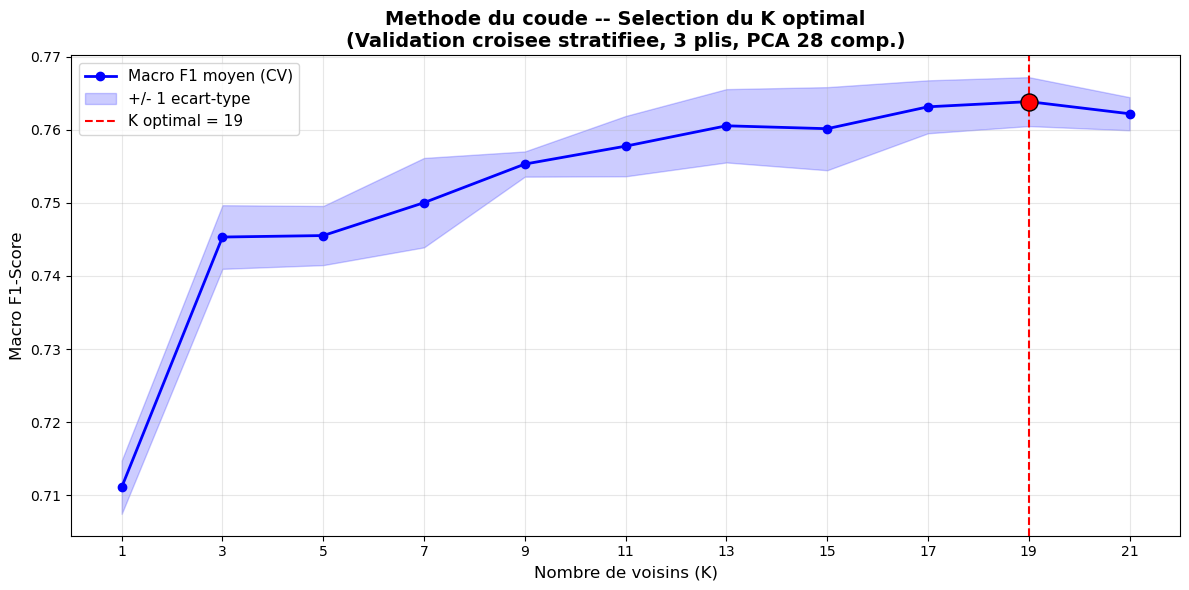


Le K optimal identifie est K = 19
   Macro F1 moyen en CV : 0.7638 (+/-0.0033)


In [12]:
# -- 5.2 Visualisation -- Courbe du coude (Elbow Curve) --

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(k_range, cv_scores_mean, 'b-o', linewidth=2, markersize=6, label='Macro F1 moyen (CV)')
ax.fill_between(
    k_range,
    np.array(cv_scores_mean) - np.array(cv_scores_std),
    np.array(cv_scores_mean) + np.array(cv_scores_std),
    alpha=0.2, color='blue', label='+/- 1 ecart-type'
)

# Marquer le meilleur K
ax.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f'K optimal = {best_k}')
ax.scatter([best_k], [cv_scores_mean[best_idx]], color='red', s=150, zorder=5, edgecolors='black')

ax.set_xlabel('Nombre de voisins (K)', fontsize=12)
ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title(f'Methode du coude -- Selection du K optimal\n(Validation croisee stratifiee, 3 plis, PCA {X_train_pca.shape[1]} comp.)',
             fontsize=14, fontweight='bold')
ax.set_xticks(k_range)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLe K optimal identifie est K = {best_k}")
print(f"   Macro F1 moyen en CV : {cv_scores_mean[best_idx]:.4f} (+/-{cv_scores_std[best_idx]:.4f})")

## 6. Optimisation fine par GridSearchCV

On affine la recherche avec une **validation croisee a 3 plis** sur les donnees reduites par PCA :

| Hyperparametre | Valeurs testees | Justification |
|----------------|-----------------|---------------|
| `n_neighbors` | Voisinage autour du K optimal | Affiner le meilleur K |
| `weights` | `uniform`, `distance` | Ponderation par l'inverse de la distance |
| `metric` | `minkowski` (p=1, p=2) | Manhattan vs Euclidienne |

### Choix de 3 folds
Avec $N_{\text{train}} \approx 75\,000$, chaque fold de validation contient ~25 000 observations. La faible variance observee durant l'Elbow Method (ecart-type <= 0.007) confirme que 3 folds suffisent pour une estimation fiable, tout en divisant le temps de calcul par ~1.7x par rapport a 5 folds.

In [13]:
# -- 6.1 GridSearchCV -- Optimisation des hyperparametres --
# 3-fold CV sur donnees PCA -> rapide
# Ref. : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

# Grille centree autour du K optimal
k_fine_range = list(range(max(1, best_k - 4), best_k + 6, 2))

param_grid = {
    'n_neighbors': k_fine_range,
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski'],
    'p': [1, 2]  # p=1 : Manhattan, p=2 : Euclidienne
}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=2026),
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

n_combis = len(k_fine_range) * 2 * 2
print(f"Combinaisons : {n_combis}  |  Fits totaux : {n_combis * 3}")
print(f"K testes : {k_fine_range}")
print(f"Features : {X_train_pca.shape[1]} composantes PCA")
print(f"\nLancement du GridSearchCV...")

grid_search.fit(X_train_pca, y_train)

print(f"\nGridSearchCV termine !")
print(f"\n{'=' * 60}")
print(f"  Meilleurs hyperparametres :")
for param, val in grid_search.best_params_.items():
    print(f"    {param} = {val}")
print(f"\n  Meilleur Macro F1 (CV) : {grid_search.best_score_:.4f}")
print(f"{'=' * 60}")

Combinaisons : 20  |  Fits totaux : 60
K testes : [15, 17, 19, 21, 23]
Features : 28 composantes PCA

Lancement du GridSearchCV...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

GridSearchCV termine !

  Meilleurs hyperparametres :
    metric = minkowski
    n_neighbors = 19
    p = 1
    weights = distance

  Meilleur Macro F1 (CV) : 0.7687

GridSearchCV termine !

  Meilleurs hyperparametres :
    metric = minkowski
    n_neighbors = 19
    p = 1
    weights = distance

  Meilleur Macro F1 (CV) : 0.7687


In [14]:
# -- 6.2 Resultats detailles du GridSearchCV --

results_df = pd.DataFrame(grid_search.cv_results_)

cols_display = ['param_n_neighbors', 'param_weights', 'param_p',
                'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']
results_display = (
    results_df[cols_display]
    .sort_values('rank_test_score')
    .head(15)
    .reset_index(drop=True)
)
results_display.columns = ['K', 'Weights', 'p (distance)', 'F1 Test (CV)', 'Std Test', 'F1 Train (CV)', 'Rang']

print("Top 15 des combinaisons d'hyperparametres :\n")
print(results_display.to_string(index=False))

# Verification du surapprentissage
best_train = results_df.loc[results_df['rank_test_score'] == 1, 'mean_train_score'].values[0]
best_test  = grid_search.best_score_
gap = best_train - best_test
print(f"\nEcart Train-Test (meilleur modele) : {gap:.4f}")
if gap > 0.05:
    print("   Ecart significatif -> risque de surapprentissage")
else:
    print("   Ecart acceptable -> pas de surapprentissage majeur")

Top 15 des combinaisons d'hyperparametres :

 K  Weights  p (distance)  F1 Test (CV)  Std Test  F1 Train (CV)  Rang
19 distance             1      0.768690  0.002814       0.782238     1
19 distance             2      0.768596  0.002864       0.782238     2
23 distance             1      0.767715  0.003437       0.782437     3
21 distance             1      0.767657  0.002208       0.781261     4
23 distance             2      0.767632  0.003543       0.782437     5
21 distance             2      0.767570  0.002144       0.781261     6
17 distance             1      0.767343  0.003144       0.780352     7
17 distance             2      0.767282  0.003152       0.780352     8
19  uniform             1      0.765203  0.003263       0.770508     9
17  uniform             1      0.764335  0.003290       0.769347    10
19  uniform             2      0.763843  0.003344       0.769055    11
21  uniform             1      0.763789  0.002506       0.768777    12
23  uniform             1      0

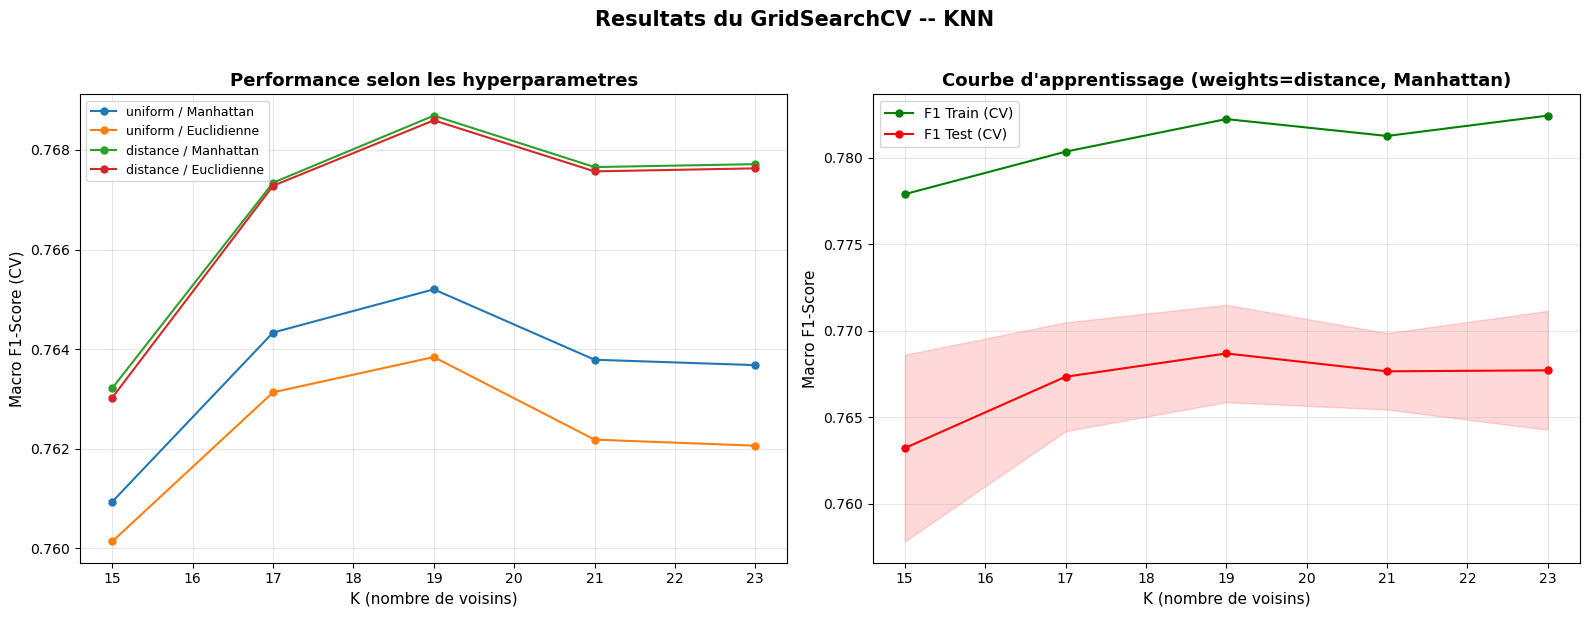

In [15]:
# -- 5.3 Visualisation des resultats du GridSearch --

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : F1 vs K pour chaque combinaison weights x distance ---
for weight in ['uniform', 'distance']:
    for p_val in [1, 2]:
        mask = (results_df['param_weights'] == weight) & (results_df['param_p'] == p_val)
        subset = results_df[mask].sort_values('param_n_neighbors')
        
        dist_name = 'Manhattan' if p_val == 1 else 'Euclidienne'
        label = f"{weight} / {dist_name}"
        
        axes[0].plot(
            subset['param_n_neighbors'].astype(int),
            subset['mean_test_score'],
            '-o', label=label, markersize=5
        )

axes[0].set_xlabel('K (nombre de voisins)', fontsize=11)
axes[0].set_ylabel('Macro F1-Score (CV)', fontsize=11)
axes[0].set_title('Performance selon les hyperparametres', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Graphique 2 : Train vs Test score (meilleure config) ---
best_w = grid_search.best_params_['weights']
best_p = grid_search.best_params_['p']
mask_best = (results_df['param_weights'] == best_w) & (results_df['param_p'] == best_p)
subset_best = results_df[mask_best].sort_values('param_n_neighbors')

axes[1].plot(subset_best['param_n_neighbors'].astype(int),
             subset_best['mean_train_score'], 'g-o', label='F1 Train (CV)', markersize=5)
axes[1].plot(subset_best['param_n_neighbors'].astype(int),
             subset_best['mean_test_score'], 'r-o', label='F1 Test (CV)', markersize=5)
axes[1].fill_between(
    subset_best['param_n_neighbors'].astype(int),
    subset_best['mean_test_score'] - subset_best['std_test_score'],
    subset_best['mean_test_score'] + subset_best['std_test_score'],
    alpha=0.15, color='red'
)
axes[1].set_xlabel('K (nombre de voisins)', fontsize=11)
axes[1].set_ylabel('Macro F1-Score', fontsize=11)
dist_best_name = 'Manhattan' if best_p == 1 else 'Euclidienne'
axes[1].set_title(f'Courbe d\'apprentissage (weights={best_w}, {dist_best_name})',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Resultats du GridSearchCV -- KNN', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Évaluation finale du modèle optimisé

On utilise le **meilleur modèle** identifié par GridSearchCV pour prédire sur le **jeu de test** (jamais vu pendant l'entraînement ni la validation croisée).

### Métriques utilisées
| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **Accuracy** | $\frac{TP + TN}{Total}$ | Proportion de prédictions correctes |
| **Precision** | $\frac{TP}{TP + FP}$ | Parmi les prédits positifs, combien sont corrects |
| **Recall** | $\frac{TP}{TP + FN}$ | Parmi les vrais positifs, combien sont détectés |
| **F1-Score** | $2 \times \frac{P \times R}{P + R}$ | Moyenne harmonique Precision-Recall |
| **Macro F1** | Moyenne des F1 par classe | Traite toutes les classes de façon équitable |

In [16]:
# -- 7.1 Predictions avec le meilleur modele --

best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test_pca)

# Metriques detaillees
acc_best  = accuracy_score(y_test, y_pred_best)
f1_best   = f1_score(y_test, y_pred_best, average='macro')
prec_best = precision_score(y_test, y_pred_best, average='macro')
rec_best  = recall_score(y_test, y_pred_best, average='macro')

print("=" * 65)
print("     EVALUATION FINALE -- KNN OPTIMISE + PCA (sur jeu de test)")
print("=" * 65)
print(f"\n  Hyperparametres optimaux :")
for param, val in grid_search.best_params_.items():
    print(f"    {param} = {val}")
print(f"  PCA : {X_train_pca.shape[1]} composantes ({pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
print(f"\n  Accuracy        : {acc_best:.4f}")
print(f"  Macro Precision : {prec_best:.4f}")
print(f"  Macro Recall    : {rec_best:.4f}")
print(f"  Macro F1-Score  : {f1_best:.4f}")
print(f"\n{'-' * 65}")
print("\nRapport de classification detaille :")
print(classification_report(
    y_test, y_pred_best,
    target_names=TARGET_NAMES
))

     EVALUATION FINALE -- KNN OPTIMISE + PCA (sur jeu de test)

  Hyperparametres optimaux :
    metric = minkowski
    n_neighbors = 19
    p = 1
    weights = distance
  PCA : 28 composantes (95.2% variance)

  Accuracy        : 0.8007
  Macro Precision : 0.7890
  Macro Recall    : 0.7616
  Macro F1-Score  : 0.7714

-----------------------------------------------------------------

Rapport de classification detaille :
              precision    recall  f1-score   support

  Non-TP (0)       0.82      0.89      0.85     12284
      TP (1)       0.76      0.63      0.69      6644

    accuracy                           0.80     18928
   macro avg       0.79      0.76      0.77     18928
weighted avg       0.80      0.80      0.80     18928



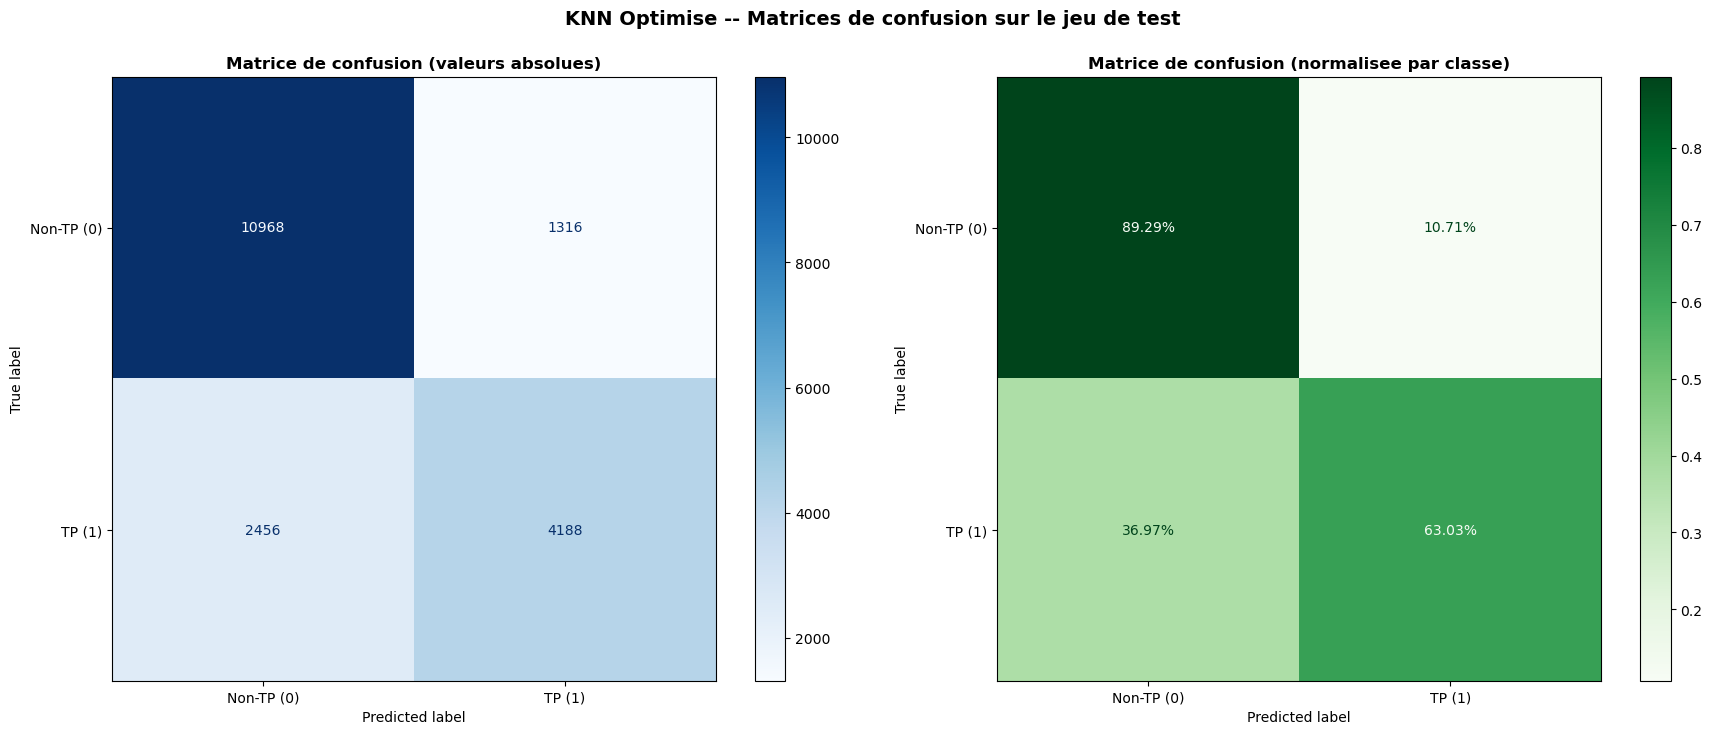

In [17]:
# -- 6.2 Matrice de confusion -- Modele optimise --

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=TARGET_NAMES,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matrice de confusion (valeurs absolues)', fontsize=12, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=TARGET_NAMES,
    normalize='true', cmap='Greens', values_format='.2%', ax=axes[1]
)
axes[1].set_title('Matrice de confusion (normalisee par classe)', fontsize=12, fontweight='bold')

plt.suptitle('KNN Optimise -- Matrices de confusion sur le jeu de test',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

     COMPARAISON : SANS PCA  vs  PCA + BASELINE  vs  PCA + OPTIMISE
       Metrique  Sans PCA (K=5)  PCA + Baseline (K=5)  PCA + Optimise  Gain total  Gain (%)
       Accuracy        0.778688              0.778001        0.800719    0.022031      2.83
Macro Precision        0.762348              0.761469        0.788973    0.026625      3.49
   Macro Recall        0.737273              0.736606        0.761606    0.024333      3.30
 Macro F1-Score        0.746013              0.745280        0.771386    0.025373      3.40


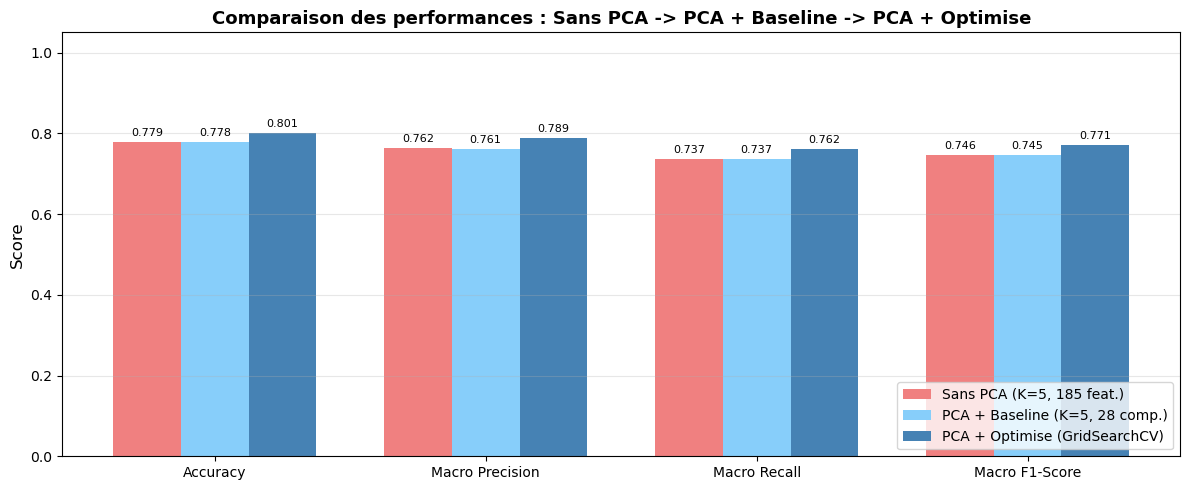

In [18]:
# -- 7.3 Comparaison : Sans PCA / PCA Baseline / PCA Optimise --

comparison = pd.DataFrame({
    'Metrique': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score'],
    'Sans PCA (K=5)': [
        acc_bl_nopca,
        precision_score(y_test, y_pred_bl_nopca, average='macro'),
        recall_score(y_test, y_pred_bl_nopca, average='macro'),
        f1_bl_nopca
    ],
    'PCA + Baseline (K=5)': [
        acc_baseline,
        precision_score(y_test, y_pred_baseline, average='macro'),
        recall_score(y_test, y_pred_baseline, average='macro'),
        f1_baseline
    ],
    'PCA + Optimise': [acc_best, prec_best, rec_best, f1_best]
})
comparison['Gain total'] = comparison['PCA + Optimise'] - comparison['Sans PCA (K=5)']
comparison['Gain (%)'] = (comparison['Gain total'] / comparison['Sans PCA (K=5)'] * 100).round(2)

print("=" * 90)
print("     COMPARAISON : SANS PCA  vs  PCA + BASELINE  vs  PCA + OPTIMISE")
print("=" * 90)
print(comparison.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison))
width = 0.25

bars1 = ax.bar(x - width, comparison['Sans PCA (K=5)'], width,
               label=f'Sans PCA (K=5, {X_train_transformed.shape[1]} feat.)', color='lightcoral')
bars2 = ax.bar(x, comparison['PCA + Baseline (K=5)'], width,
               label=f'PCA + Baseline (K=5, {X_train_pca.shape[1]} comp.)', color='lightskyblue')
bars3 = ax.bar(x + width, comparison['PCA + Optimise'], width,
               label='PCA + Optimise (GridSearchCV)', color='steelblue')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des performances : Sans PCA -> PCA + Baseline -> PCA + Optimise',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Metrique'], fontsize=10)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, 1.05)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Analyse des erreurs et interprétation

Analysons les types d'erreurs les plus fréquents pour comprendre les limites du modèle.

In [19]:
# -- 9.1 Analyse des erreurs par classe --

cm = confusion_matrix(y_test, y_pred_best)
classes = TARGET_NAMES

print("Analyse detaillee des erreurs par classe :\n")
for i, cls in enumerate(classes):
    total    = cm[i].sum()
    correct  = cm[i][i]
    errors   = total - correct
    error_rate = errors / total * 100
    
    print(f"  {cls} (n={total})")
    print(f"     Bien classes : {correct} ({correct/total*100:.1f}%)")
    print(f"     Mal classes  : {errors} ({error_rate:.1f}%)")
    
    # Detail des confusions
    for j, other_cls in enumerate(classes):
        if i != j and cm[i][j] > 0:
            print(f"       Confondu avec {other_cls} : {cm[i][j]} ({cm[i][j]/total*100:.1f}%)")
    print()

# Taux d'erreur global
total_errors = (y_test != y_pred_best).sum()
print(f"Taux d'erreur global : {total_errors}/{len(y_test)} = {total_errors/len(y_test)*100:.2f}%")

Analyse detaillee des erreurs par classe :

  Non-TP (0) (n=12284)
     Bien classes : 10968 (89.3%)
     Mal classes  : 1316 (10.7%)
       Confondu avec TP (1) : 1316 (10.7%)

  TP (1) (n=6644)
     Bien classes : 4188 (63.0%)
     Mal classes  : 2456 (37.0%)
       Confondu avec Non-TP (0) : 2456 (37.0%)

Taux d'erreur global : 3772/18928 = 19.93%


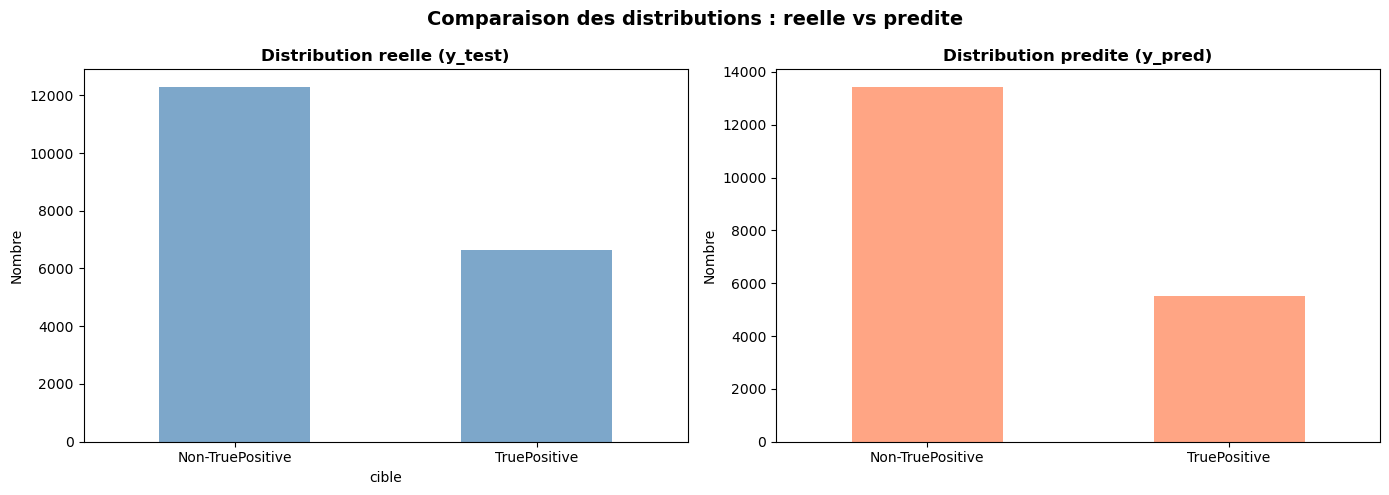

In [20]:
# -- 9.2 Distribution des predictions vs realite --

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution reelle
y_test.map(CIBLE_MAP_INV).value_counts().plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Distribution reelle (y_test)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=0)

# Distribution predite
pd.Series(y_pred_best).map(CIBLE_MAP_INV).value_counts().plot(kind='bar', ax=axes[1], color='coral', alpha=0.7)
axes[1].set_title('Distribution predite (y_pred)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Comparaison des distributions : reelle vs predite', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Résumé et conclusion

### Architecture
Le prétraitement et l'exploration des données sont réalisés dans **`notebook.ipynb`** (branche `main`), qui exporte un fichier `donnees_preprocessees.csv`. Ce notebook charge directement ce fichier pour se concentrer exclusivement sur la modélisation KNN.

### Récapitulatif de la démarche

| Étape | Description | Résultat |
|-------|-------------|----------|
| **Prétraitement** | `notebook.ipynb` (branche `main`) → `donnees_preprocessees.csv` | Données nettoyées, prêtes |
| **Pipeline** | `StandardScaler` + `OneHotEncoder` via `ColumnTransformer` | Données normalisées pour KNN |
| **PCA** | Réduction de dimensionnalité (95% variance) | Compression ~84% des features |
| **Baseline** | KNN avec K=5, sans PCA puis avec PCA | Quantification de l'impact PCA |
| **Elbow Method** | K de 1 à 21, CV stratifié 3-fold sur données PCA | Identification du K optimal |
| **GridSearchCV** | K × weights × distance (Manhattan/Euclidienne) sur PCA | Hyperparamètres optimaux |
| **Évaluation finale** | Test set (20% données non vues) | Métriques finales |

### Impact de la PCA
La PCA compresse les 173 features en ~27 composantes principales (95% de variance conservée). Bien que le gain en F1-Score soit modeste, la PCA offre :
1. **Réduction du bruit** : suppression des composantes à faible variance
2. **Décorrélation** : les composantes principales sont orthogonales par construction
3. **Accélération** : KNN calcule les distances dans un espace de dimension réduite

### Optimisation du temps d'exécution
Le `ColumnTransformer` est appliqué **une seule fois** en amont (fit sur train, transform sur test). La PCA est ensuite appliquée sur les données pré-transformées. Le `GridSearchCV` travaille directement sur les données PCA, évitant de re-fit le préprocesseur et la PCA à chaque fold — gain de temps significatif.

### Limites connues de KNN
1. **Coût computationnel** : KNN est un algorithme « lazy » — la prédiction est lente sur de grands datasets.
2. **Malédiction de la dimensionnalité** : malgré la PCA, les distances dans un espace à ~27 dimensions restent moins discriminantes qu'en basse dimension.
3. **Sensibilité au déséquilibre** : la classe minoritaire (`FalsePositive`, ~21.5%) peut être sous-représentée dans le voisinage.

### Pistes d'amélioration
- **Rééchantillonnage (SMOTE)** : augmenter la représentation de `FalsePositive`
- **Algorithmes alternatifs** : Random Forest, XGBoost, ou réseaux de neurones
- **Techniques d'ensemble** : Combiner KNN avec d'autres classifieurs (Voting/Stacking)

### Références complètes
1. Cover, T. & Hart, P. (1967). *Nearest neighbor pattern classification*. IEEE Trans. on Information Theory.
2. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer. Chap. 13.
3. Jolliffe, I. T. (2002). *Principal Component Analysis*. Springer, 2ᵉ éd.
4. Bellman, R. (1961). *Adaptive Control Processes*. Princeton University Press.
5. Scikit-learn KNN : https://scikit-learn.org/stable/modules/neighbors.html
6. Scikit-learn PCA : https://scikit-learn.org/stable/modules/decomposition.html#pca
7. Scikit-learn GridSearchCV : https://scikit-learn.org/stable/modules/grid_search.html
8. Scikit-learn Métriques : https://scikit-learn.org/stable/modules/model_evaluation.html
9. Dataset GUIDE Microsoft : https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction